
Dataset: control
Idx |        A ± error            |        k' (median, 16–84%)         | w_up   w_lo
-----------------------------------------------------------------------------------------------
001 |  3.2888e-08 ± 3.56e-08        |  2.1610e+01  +4.01e+02  -1.78e+01     |  18.576  0.823
002 |  3.6900e-08 ± 1.59e-08        |  2.8929e+01  +1.17e+02  -1.89e+01     |  4.047  0.654
003 |  4.3100e-08 ± 2.47e-08        |  1.6855e+01  +1.23e+02  -1.22e+01     |  7.325  0.726

Average k' (linear average of medians):
k'_avg = 2.2465e+01
Average k' bounds (weighted-bound rule):
Upper: 2.4673e+02   (w_up_avg=9.9830)
Lower: 5.9716e+00   (w_lo_avg=0.7342)
Asymmetric: +2.24e+02  -1.65e+01

Dataset: 10_fibrils
Idx |        A ± error            |        k' (median, 16–84%)         | w_up   w_lo
-----------------------------------------------------------------------------------------------
001 |  2.2870e-08 ± 2.26e-08        |  7.1737e+01  +1.22e+03  -5.83e+01     |  16.976  0.813
002 |  1.0182e-07 

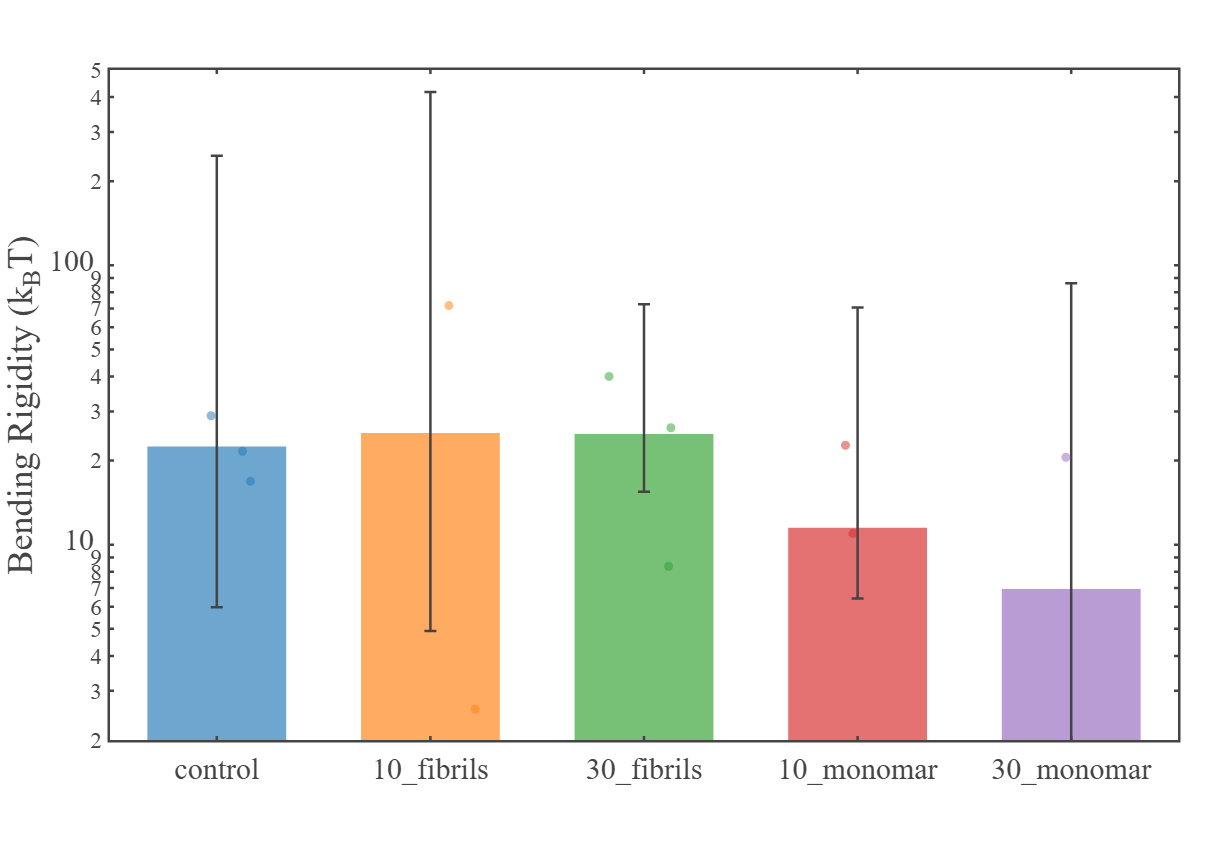

In [123]:
import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go

# -------------------------------------------------
# Custom Plotly Template (provided by you)
# -------------------------------------------------
fig_template = go.layout.Template()
fig_template.layout = {
    'template': 'simple_white+presentation',
    'autosize': False,
    'width': 800,
    'height': 600,
    'xaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.5,
        'tickwidth': 2.5,
        'ticklen': 4,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'yaxis': {
        'ticks': 'inside',
        'mirror': 'ticks',
        'linewidth': 2.5,
        'tickwidth': 2.5,
        'ticklen': 4,
        'showline': True,
        'showgrid': False,
        'zerolinecolor': 'white',
    },
    'font': {
        'family': 'mathjax',
        'size': 30,
    }
}

# -------------------------------------------------
# Monte Carlo settings
# -------------------------------------------------
N_MC = 300_000
rng = np.random.default_rng(42)

A_COL = "A"
ERR_COL = "error"

# -------------------------------------------------
# 1. Load data (A and error)
# -------------------------------------------------
def load_data_with_error(file_path, a_col=A_COL, err_col=ERR_COL):
    df = pd.read_excel(file_path)

    if a_col not in df.columns or err_col not in df.columns:
        raise KeyError(
            f"Need columns '{a_col}' and '{err_col}' in {file_path}. Found: {list(df.columns)}"
        )

    df[a_col] = pd.to_numeric(df[a_col], errors="coerce")
    df[err_col] = pd.to_numeric(df[err_col], errors="coerce")

    df = df.dropna(subset=[a_col, err_col])
    df = df[(df[a_col] > 0) & (df[err_col] >= 0)]

    return df[a_col].to_numpy(dtype=float), df[err_col].to_numpy(dtype=float)


# -------------------------------------------------
# 2. Monte Carlo for one membrane: A ± error -> k samples
# -------------------------------------------------
def mc_k_from_a(a, sigma_a, C, N=N_MC):
    if sigma_a == 0 or np.isclose(sigma_a, 0):
        k = C / (a**3)
        return np.full(N, k, dtype=float)

    a_s = rng.normal(a, sigma_a, size=N)
    a_s = a_s[a_s > 0]

    while a_s.size < N:
        extra = rng.normal(a, sigma_a, size=N - a_s.size)
        extra = extra[extra > 0]
        a_s = np.concatenate([a_s, extra])

    a_s = a_s[:N]
    return C / (a_s**3)


# -------------------------------------------------
# 3. Summary: median + 16–84% (asymmetric)
# -------------------------------------------------
def summarize(samples):
    med = np.median(samples)
    p16 = np.percentile(samples, 16)
    p84 = np.percentile(samples, 84)
    return med, p16, p84


# -------------------------------------------------
# 4. Process one dataset using YOUR weighted-bound rule
#    - Per membrane: MC -> (med, p16, p84)
#    - Average k: linear average of the 3 medians
#    - Average bounds:
#         w_up_i = (p84_i - med_i)/med_i
#         w_lo_i = (med_i - p16_i)/med_i
#         w_up_avg = mean(w_up_i), w_lo_avg = mean(w_lo_i)
#         kavg_upper = kavg * (1 + w_up_avg)
#         kavg_lower = kavg * (1 - w_lo_avg)
# -------------------------------------------------
def process_dataset_weighted_bounds(file_path, beta, k_J, k_kT):
    name = os.path.basename(file_path).replace(".xlsx", "")

    a_vals, sig_vals = load_data_with_error(file_path, A_COL, ERR_COL)

    C = k_J / (k_kT * beta**3)

    k_med_list, k_p16_list, k_p84_list = [], [], []
    w_up_list, w_lo_list = [], []

    # Print side-by-side
    print(f"\n==============================")
    print(f"Dataset: {name}")
    print(f"==============================")
    print("Idx |        A ± error            |        k' (median, 16–84%)         | w_up   w_lo")
    print("-"*95)

    for i, (a, s) in enumerate(zip(a_vals, sig_vals), start=1):
        ks = mc_k_from_a(a, s, C, N=N_MC)
        k_med, k_p16, k_p84 = summarize(ks)

        # normalized bounds relative to median
        w_up = (k_p84 - k_med) / k_med if k_med > 0 else np.nan
        w_lo = (k_med - k_p16) / k_med if k_med > 0 else np.nan

        k_med_list.append(k_med)
        k_p16_list.append(k_p16)
        k_p84_list.append(k_p84)
        w_up_list.append(w_up)
        w_lo_list.append(w_lo)

        print(
            f"{i:03d} | {a: .4e} ± {s:.2e}        | "
            f"{k_med: .4e}  +{(k_p84-k_med):.2e}  -{(k_med-k_p16):.2e}     | "
            f"{w_up: .3f} {w_lo: .3f}"
        )

    k_med_arr = np.array(k_med_list, dtype=float)
    w_up_arr = np.array(w_up_list, dtype=float)
    w_lo_arr = np.array(w_lo_list, dtype=float)

    # Average k by linear average of medians
    kavg = float(np.mean(k_med_arr))

    # Average the relative bounds
    w_up_avg = float(np.nanmean(w_up_arr))
    w_lo_avg = float(np.nanmean(w_lo_arr))

    # Bounds for average k
    kavg_upper = kavg * (1.0 + w_up_avg)
    kavg_lower = kavg * (1.0 - w_lo_avg)

    print("\nAverage k' (linear average of medians):")
    print(f"k'_avg = {kavg:.4e}")
    print("Average k' bounds (weighted-bound rule):")
    print(f"Upper: {kavg_upper:.4e}   (w_up_avg={w_up_avg:.4f})")
    print(f"Lower: {kavg_lower:.4e}   (w_lo_avg={w_lo_avg:.4f})")
    print(f"Asymmetric: +{(kavg_upper-kavg):.2e}  -{(kavg-kavg_lower):.2e}")

    # For plotting strip: per-membrane k medians
    # For plotting bar: average k and its bounds
    return name, k_med_arr, (kavg, kavg_lower, kavg_upper)


# -------------------------------------------------
# 5. Main
# -------------------------------------------------
def main():

    beta = 1.96e11
    k_J = 4.56e-8
    k_kT = 4.11e-21

    file_paths = [
        r"D:\Atanu\Narendran_GUV\Narendran_GUV\control.xlsx",
        r"D:\Atanu\Narendran_GUV\Narendran_GUV\10_fibrils.xlsx",
        r"D:\Atanu\Narendran_GUV\Narendran_GUV\30_fibrils.xlsx",
        r"D:\Atanu\Narendran_GUV\Narendran_GUV\10_monomar.xlsx",
        r"D:\Atanu\Narendran_GUV\Narendran_GUV\30_monomar.xlsx",
    ]

    results = []
    all_k_points = {}  # per-membrane medians

    for path in file_paths:
        name, k_medians_per_membrane, (kavg, kavg_lower, kavg_upper) = process_dataset_weighted_bounds(
            path, beta, k_J, k_kT
        )
        all_k_points[name] = k_medians_per_membrane
        results.append((name, kavg, kavg_lower, kavg_upper))

    # -------------------------------------------------
    # Plot: per-membrane strip + average bar with weighted-bound error bars
    # -------------------------------------------------
    names = [r[0] for r in results]
    centers = [r[1] for r in results]
    err_low = [r[1] - r[2] for r in results]   # center - lower
    err_high = [r[3] - r[1] for r in results]  # upper - center

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    color_map = {n: colors[i % len(colors)] for i, n in enumerate(names)}

    rng_plot = np.random.default_rng(42)
    jitter_width = 0.22

    fig = go.Figure()

    # 1) Per-membrane points: per-membrane k medians
    for i, n in enumerate(names):
        k_vals = all_k_points[n]
        x_jitter = rng_plot.uniform(-jitter_width, jitter_width, size=len(k_vals))
        x = i + x_jitter

        fig.add_trace(
            go.Scatter(
                x=x,
                y=k_vals,
                mode="markers",
                marker=dict(size=9, opacity=0.5, color=color_map[n], line=dict(width=0)),
                hovertemplate=(f"<b>{n}</b><br>k'=%{{y:.3e}}<extra></extra>"),
                showlegend=False
            )
        )

    # 2) Average bars with weighted-bound rule error bars
    fig.add_trace(
        go.Bar(
            x=list(range(len(names))),
            y=centers,
            error_y=dict(
                type='data',
                symmetric=False,
                array=err_high,
                arrayminus=err_low,
                thickness=2.5,
                width=6
            ),
            marker=dict(color=[color_map[n] for n in names], opacity=0.65),
            customdata=names,
            hovertemplate=(
                "<b>%{customdata}</b><br>"
                "k'_avg=%{y:.3e}<br>"
                "+err=%{error_y.array:.3e}<br>"
                "-err=%{error_y.arrayminus:.3e}<extra></extra>"
            ),
            showlegend=False,
        )
    )

    fig.update_layout(
        template=fig_template,
        width=1200,
        height=850,
        yaxis=dict(
            type="log",
            range=[np.log10(2), np.log10(500)],
            title="Bending Rigidity (k<sub>B</sub>T)"
        ),
        xaxis=dict(
            tickmode="array",
            tickvals=list(range(len(names))),
            ticktext=names,
        ),
        margin=dict(l=110, r=50, t=70, b=110),
        bargap=0.35
    )

    fig.show()


if __name__ == "__main__":
    main()
